# Mistake Identification in Pedagogical Conversations

## Problem Statement
Given a tutoring conversation where a student makes a mistake, classify whether the tutor's response successfully identifies the student's mistake.

**Classification Labels:**
- **Yes**: The tutor clearly identifies the mistake
- **To some extent**: The tutor partially addresses the mistake
- **No**: The tutor does not identify the mistake

## Dataset Structure
- **trainset.json**: 300 conversations with labels (2,400 samples) - Used for training
- **dev_testset.json**: 41 conversations WITHOUT labels (328 samples) - For inference/predictions
- **testset.json**: 150 conversations WITHOUT labels (1,200 samples) - For final predictions

## Approach
We'll use a fine-tuned transformer model for sequence classification:

1. **Model Choice**: DeBERTa-v3-base for excellent reasoning capabilities
2. **Training Strategy**: Train on trainset with validation split
3. **Evaluation**: Make predictions on dev and test sets
4. **Output**: Save predictions as CSV files for each model's responses

## 1. Import the dataset

In [83]:
import json

# Read all JSON files
json_files = [
    '../data/trainset.json',
    '../data/testset.json',
    '../data/dev_testset.json'
]

all_conversation_ids = set()

for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for item in data:
                if 'conversation_id' in item:
                    all_conversation_ids.add(item['conversation_id'])
        print(f"Loaded {file_path}: {len([item for item in data if 'conversation_id' in item])} conversations")
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print(f"\nTotal unique conversation IDs across all files: {len(all_conversation_ids)}")

Loaded ../data/trainset.json: 300 conversations
Loaded ../data/testset.json: 150 conversations
Loaded ../data/dev_testset.json: 41 conversations

Total unique conversation IDs across all files: 491


In [84]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu129
CUDA available: True
Device: NVIDIA RTX 6000 Ada Generation


## 2. Load and Explore Data

Loading datasets...
Note: Train set has labels, Dev/Test sets are for prediction only

Dataset Statistics
Training samples (with labels): 2476
Dev samples (for inference): 333
Test samples (for inference): 1214

Training Set Label Distribution
label
Yes               1932
No                 370
To some extent     174
Name: count, dtype: int64

📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!


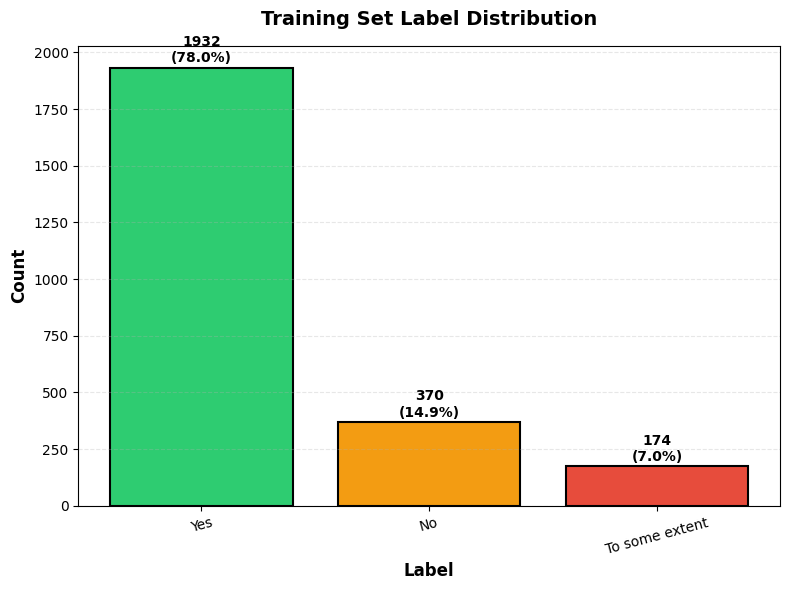


✓ Saved: label_distribution.png


In [85]:
def load_train_data(file_path):
    """Load training data with annotations (labels)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            if 'annotation' in response_data and 'Mistake_Identification' in response_data['annotation']:
                samples.append({
                    'conversation_history': conv_history,
                    'tutor_response': response_data['response'],
                    'label': response_data['annotation']['Mistake_Identification'],
                    'conversation_id': conv_id,
                    'model': model_name
                })
    
    return pd.DataFrame(samples)

def load_test_data(file_path):
    """Load test data WITHOUT annotations (for inference only)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            samples.append({
                'conversation_history': conv_history,
                'tutor_response': response_data['response'],
                'conversation_id': conv_id,
                'model': model_name
            })
    
    return pd.DataFrame(samples)

# Load datasets
print("Loading datasets...")
print("Note: Train set has labels, Dev/Test sets are for prediction only")
train_df = load_train_data('../data/trainset.json')
dev_df = load_test_data('../data/dev_testset.json')
test_df = load_test_data('../data/testset.json')

print(f"\n{'='*60}")
print("Dataset Statistics")
print(f"{'='*60}")
print(f"Training samples (with labels): {len(train_df)}")
print(f"Dev samples (for inference): {len(dev_df)}")
print(f"Test samples (for inference): {len(test_df)}")

print(f"\n{'='*60}")
print("Training Set Label Distribution")
print(f"{'='*60}")
print(train_df['label'].value_counts())
print(f"\n📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!")

# Visualize label distribution (training data only)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
counts = train_df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax.set_title('Training Set Label Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Label', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count}\n({count/len(train_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: label_distribution.png")

## 3. Data Analysis & Insights

In [86]:
# Analyze text lengths
train_df['history_length'] = train_df['conversation_history'].str.len()
train_df['response_length'] = train_df['tutor_response'].str.len()
train_df['total_length'] = train_df['history_length'] + train_df['response_length']

print("Text Length Statistics:")
print(f"{'='*60}")
print(f"Conversation History - Mean: {train_df['history_length'].mean():.0f}, Max: {train_df['history_length'].max()}")
print(f"Tutor Response - Mean: {train_df['response_length'].mean():.0f}, Max: {train_df['response_length'].max()}")
print(f"Total Length - Mean: {train_df['total_length'].mean():.0f}, Max: {train_df['total_length'].max()}")

# Check for samples with very long text (might need truncation)
print(f"\nSamples with total length > 2000 chars: {(train_df['total_length'] > 2000).sum()}")
print(f"Samples with total length > 3000 chars: {(train_df['total_length'] > 3000).sum()}")

# Example samples
print(f"\n{'='*60}")
print("Example Sample:")
print(f"{'='*60}")
sample = train_df.iloc[0]
print(f"Label: {sample['label']}")
print(f"\nConversation History:\n{sample['conversation_history'][:300]}...")
print(f"\nTutor Response:\n{sample['tutor_response']}")
print(f"{'='*60}")

Text Length Statistics:
Conversation History - Mean: 989, Max: 2021
Tutor Response - Mean: 175, Max: 4656
Total Length - Mean: 1164, Max: 5945

Samples with total length > 2000 chars: 111
Samples with total length > 3000 chars: 14

Example Sample:
Label: Yes

Conversation History:
Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  ...

Tutor Response:
Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed.


## 4. Prepare Model and Tokenizer

We'll use **DeBERTa-v3-base** which excels at natural language understanding tasks.

In [87]:
# Model selection - DeBERTa-v3-base is excellent for understanding nuanced text
MODEL_NAME = "microsoft/deberta-v3-base"
# Alternative options if needed:
# MODEL_NAME = "roberta-base"
# MODEL_NAME = "bert-base-uncased"

# Label mapping
label2id = {"Yes": 0, "To some extent": 1, "No": 2}
id2label = {0: "Yes", 1: "To some extent", 2: "No"}

print(f"Selected Model: {MODEL_NAME}")
print(f"Label mapping: {label2id}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nTokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Max length: {tokenizer.model_max_length}")

Selected Model: microsoft/deberta-v3-base
Label mapping: {'Yes': 0, 'To some extent': 1, 'No': 2}

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656


## 5. Create PyTorch Dataset

In [88]:
class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Combine conversation history and tutor response
        text = f"{row['conversation_history']} [SEP] {row['tutor_response']}"
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        
        return item

# Create datasets
MAX_LENGTH = 512

# Split training data into train and validation (80/20)
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])

print(f"Data split:")
print(f"  Training: {len(train_data)} samples")
print(f"  Validation: {len(val_data)} samples (from trainset)")
print(f"  Dev (inference): {len(dev_df)} samples (no labels)")
print(f"  Test (inference): {len(test_df)} samples (no labels)")

# Create datasets
train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)
dev_dataset = MistakeIdentificationDataset(dev_df, tokenizer, MAX_LENGTH, has_labels=False)
test_dataset = MistakeIdentificationDataset(test_df, tokenizer, MAX_LENGTH, has_labels=False)

print(f"\nDatasets created successfully!")

# Test the dataset
sample = train_dataset[0]
print(f"\nSample from training dataset:")
print(f"  Input IDs shape: {sample['input_ids'].shape}")
print(f"  Attention mask shape: {sample['attention_mask'].shape}")
print(f"  Label: {sample['labels']} ({id2label[sample['labels'].item()]})")

sample_inf = dev_dataset[0]
print(f"\nSample from inference dataset (dev):")
print(f"  Input IDs shape: {sample_inf['input_ids'].shape}")
print(f"  Attention mask shape: {sample_inf['attention_mask'].shape}")
print(f"  Has label: {'labels' in sample_inf}")

Data split:
  Training: 1980 samples
  Validation: 496 samples (from trainset)
  Dev (inference): 333 samples (no labels)
  Test (inference): 1214 samples (no labels)

Datasets created successfully!

Sample from training dataset:
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Label: 0 (Yes)

Sample from inference dataset (dev):
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Has label: False


## 6. Compute Class Weights (Handle Imbalanced Data)

In [89]:
# Calculate class weights to handle imbalanced data
train_labels = train_df['label'].map(label2id).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Class Distribution in Training Set:")
print(f"{'='*60}")
for label, count in train_df['label'].value_counts().items():
    percentage = (count / len(train_df)) * 100
    weight = class_weights[label2id[label]]
    print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%) -> weight: {weight:.3f}")

print(f"\n{'='*60}")
print("Class weights will help the model focus on minority classes!")

Class Distribution in Training Set:
  Yes                 : 1932 samples ( 78.0%) -> weight: 0.427
  No                  :  370 samples ( 14.9%) -> weight: 2.231
  To some extent      :  174 samples (  7.0%) -> weight: 4.743

Class weights will help the model focus on minority classes!


## 7. Define Custom Trainer with Weighted Loss

In [90]:
from torch import nn

class WeightedTrainer(Trainer):
    """Custom Trainer with weighted loss for imbalanced data."""
    
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute weighted loss for imbalanced classes.
        Accepts **kwargs to handle additional arguments from newer Transformers versions.
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Apply weighted cross-entropy loss
        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        else:
            loss_fct = nn.CrossEntropyLoss()
            
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

print("Custom Trainer with weighted loss defined!")

Custom Trainer with weighted loss defined!


## 8. Define Metrics

In [91]:
def compute_metrics(eval_pred):
    """Compute comprehensive metrics for evaluation."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    
    # Overall metrics
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2]
    )
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_yes': f1[0],
        'f1_to_some_extent': f1[1],
        'f1_no': f1[2],
        'precision_yes': precision[0],
        'precision_to_some_extent': precision[1],
        'precision_no': precision[2],
        'recall_yes': recall[0],
        'recall_to_some_extent': recall[1],
        'recall_no': recall[2],
    }

print("Metrics computation function defined!")

Metrics computation function defined!


## 9. Initialize Model and Training Configuration

In [92]:
# Load pre-trained model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results/mistake-identification-deberta",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
    report_to="none",
    seed=42,
)

print(f"\n{'='*60}")
print("Training Configuration")
print(f"{'='*60}")
print(f"Model: {MODEL_NAME}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Warmup ratio: {training_args.warmup_ratio}")
print(f"Weight decay: {training_args.weight_decay}")
print(f"FP16: {training_args.fp16}")
print(f"{'='*60}")

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda

Training Configuration
Model: microsoft/deberta-v3-base
Batch size: 8
Learning rate: 2e-05
Epochs: 10
Warmup ratio: 0.1
Weight decay: 0.01
FP16: True


## 10. Initialize Trainer and Start Training

In [93]:
# Initialize the custom trainer
trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Use validation split from trainset
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Trainer initialized with:")
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)} (from trainset)")
print(f"  - Weighted loss (handles class imbalance)")
print(f"  - Early stopping (patience=2)")
print(f"  - Best model selection based on F1-macro")

print(f"\n{'='*60}")
print("Starting Training...")
print(f"{'='*60}\n")

# Train the model
train_result = trainer.train()

print(f"\n{'='*60}")
print("Training Completed!")
print(f"{'='*60}")
print(f"Final training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")

# Save the best model
best_model_path = "./best_model/mistake-identification"
trainer.save_model(best_model_path)
tokenizer.save_pretrained(best_model_path)
print(f"\n✓ Best model saved to: {best_model_path}")

Trainer initialized with:
  - Training samples: 1980
  - Validation samples: 496 (from trainset)
  - Weighted loss (handles class imbalance)
  - Early stopping (patience=2)
  - Best model selection based on F1-macro

Starting Training...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
1,1.101700,1.052486,0.798387,0.483026,0.774274,0.884371,0.000000,0.564706,0.870000,0.000000,0.500000,0.899225,0.000000,0.648649
2,0.987800,0.931343,0.790323,0.537355,0.794037,0.890625,0.108108,0.613333,0.897638,0.102564,0.605263,0.883721,0.114286,0.621622
3,0.879600,0.914201,0.715726,0.575735,0.758864,0.821480,0.218978,0.686747,0.937086,0.147059,0.619565,0.731266,0.428571,0.770270
4,0.721300,0.815328,0.709677,0.595404,0.764001,0.819912,0.253012,0.713287,0.945946,0.160305,0.739130,0.723514,0.600000,0.689189
5,0.638500,0.917415,0.768145,0.602111,0.797582,0.865014,0.226087,0.715232,0.926254,0.162500,0.701299,0.811370,0.371429,0.729730
6,0.517200,0.956187,0.794355,0.631763,0.818861,0.882907,0.267857,0.744526,0.921348,0.194805,0.809524,0.847545,0.428571,0.689189
7,0.467200,1.099931,0.745968,0.586778,0.781337,0.848315,0.211382,0.700637,0.929231,0.147727,0.662651,0.780362,0.371429,0.743243
8,0.379500,1.089733,0.806452,0.635290,0.824065,0.888000,0.262626,0.755245,0.917355,0.203125,0.782609,0.860465,0.371429,0.729730
9,0.233200,1.270443,0.806452,0.620077,0.820407,0.890066,0.239130,0.731034,0.913043,0.192982,0.746479,0.868217,0.314286,0.716216
10,0.250500,1.308084,0.828629,0.645386,0.835191,0.902216,0.292683,0.741259,0.910526,0.255319,0.768116,0.894057,0.342857,0.716216



Training Completed!
Final training loss: 0.6117
Training time: 325.71 seconds

✓ Best model saved to: ./best_model/mistake-identification

✓ Best model saved to: ./best_model/mistake-identification


## 11. Evaluate on Validation Set (from trainset)

VALIDATION SET EVALUATION (from trainset)



Validation Set Metrics:
  Accuracy: 0.8286
  F1 (Macro): 0.6454
  F1 (Weighted): 0.8352

Per-Class F1 Scores:
  Yes: 0.9022
  To some extent: 0.2927
  No: 0.7413


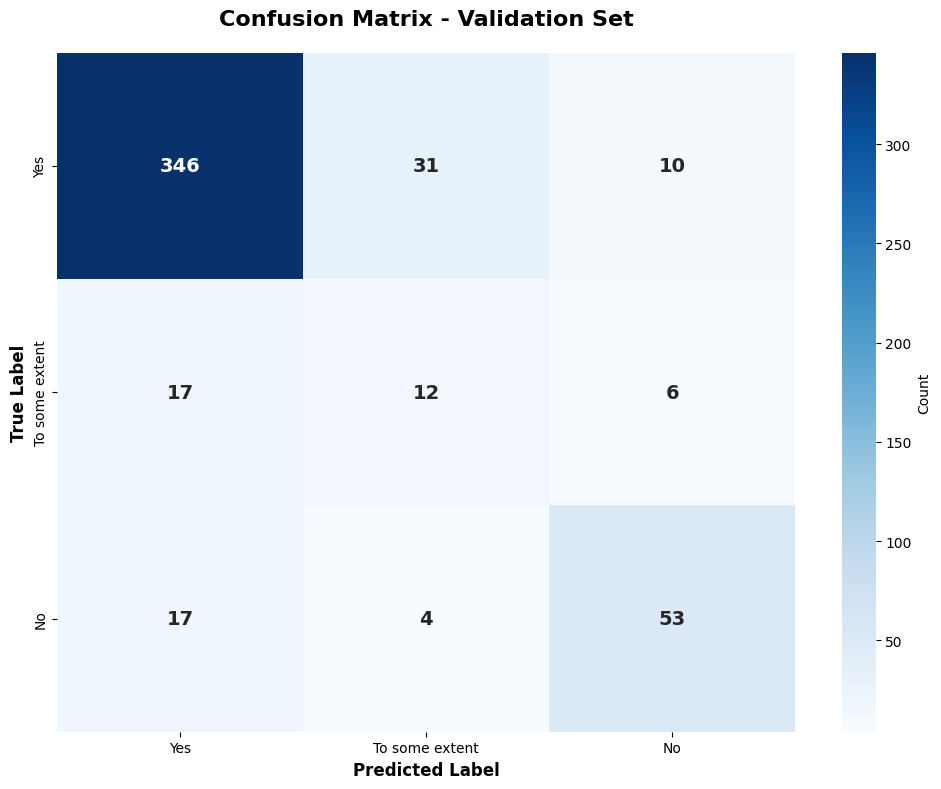


✓ Saved: confusion_matrix_validation.png

Classification Report - Validation Set
                precision    recall  f1-score   support

           Yes     0.9105    0.8941    0.9022       387
To some extent     0.2553    0.3429    0.2927        35
            No     0.7681    0.7162    0.7413        74

      accuracy                         0.8286       496
     macro avg     0.6447    0.6510    0.6454       496
  weighted avg     0.8430    0.8286    0.8352       496



In [94]:
print(f"{'='*60}")
print("VALIDATION SET EVALUATION (from trainset)")
print(f"{'='*60}\n")

# Evaluate on validation set
val_results = trainer.evaluate(val_dataset)

print("Validation Set Metrics:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")
print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

# Get predictions
val_predictions = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_predictions.predictions, axis=1)
val_true_labels = val_predictions.label_ids

# Confusion Matrix
cm_val = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Yes', 'To some extent', 'No'],
            yticklabels=['Yes', 'To some extent', 'No'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: confusion_matrix_validation.png")

# Detailed Classification Report
print(f"\n{'='*60}")
print("Classification Report - Validation Set")
print(f"{'='*60}")
print(classification_report(val_true_labels, val_pred_labels, 
                          target_names=['Yes', 'To some extent', 'No'],
                          digits=4))

## 12. Make Predictions on Dev and Test Sets (No Labels)


MAKING PREDICTIONS ON DEV & TEST SETS

Predicting on Dev set...


✓ Dev predictions saved to: dev_predictions.csv (333 samples)

Predicting on Test set...


✓ Test predictions saved to: test_predictions.csv (1214 samples)

Prediction Distribution

Dev Set:
Yes               235
No                 72
To some extent     26
Name: count, dtype: int64

Test Set:
Yes               853
No                216
To some extent    145
Name: count, dtype: int64


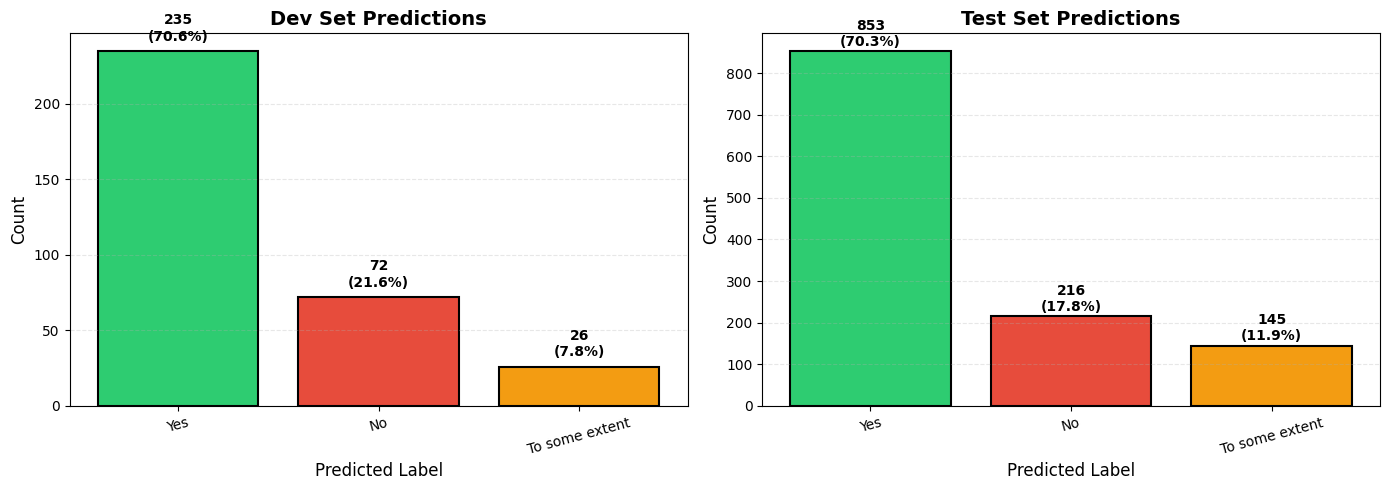


✓ Saved: prediction_distributions.png

Sample Predictions (Dev Set - First 5)

Sample 1:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: No she got 5 gift cards and in total 15 thank you cards. The 15 make up 30% of the class. How many s...
  Predicted: No
  Confidence: 0.978
  ------------------------------------------------------------

Sample 2:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: Let's reconsider the calculation for the number of thank you cards; if she got 5 gift cards, and 1/3...
  Predicted: No
  Confidence: 0.978
  ------------------------------------------------------------

Sample 3:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: I see where you're coming from, but remember, we already determined 

In [95]:
print(f"\n{'='*60}")
print("MAKING PREDICTIONS ON DEV & TEST SETS")
print(f"{'='*60}\n")

# Make predictions on dev set
print("Predicting on Dev set...")
dev_predictions = trainer.predict(dev_dataset)
dev_pred_labels = np.argmax(dev_predictions.predictions, axis=1)
dev_pred_probs = torch.softmax(torch.tensor(dev_predictions.predictions), dim=1).numpy()

# Add predictions to dev dataframe
dev_results_df = dev_df.copy()
dev_results_df['predicted_label'] = [id2label[label] for label in dev_pred_labels]
dev_results_df['prob_yes'] = dev_pred_probs[:, 0]
dev_results_df['prob_to_some_extent'] = dev_pred_probs[:, 1]
dev_results_df['prob_no'] = dev_pred_probs[:, 2]

# Save dev predictions
dev_results_df.to_csv('dev_predictions.csv', index=False)
print(f"✓ Dev predictions saved to: dev_predictions.csv ({len(dev_results_df)} samples)")

# Make predictions on test set
print("\nPredicting on Test set...")
test_predictions = trainer.predict(test_dataset)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_pred_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

# Add predictions to test dataframe
test_results_df = test_df.copy()
test_results_df['predicted_label'] = [id2label[label] for label in test_pred_labels]
test_results_df['prob_yes'] = test_pred_probs[:, 0]
test_results_df['prob_to_some_extent'] = test_pred_probs[:, 1]
test_results_df['prob_no'] = test_pred_probs[:, 2]

# Save test predictions
test_results_df.to_csv('test_predictions.csv', index=False)
print(f"✓ Test predictions saved to: test_predictions.csv ({len(test_results_df)} samples)")

# Show prediction distribution
print(f"\n{'='*60}")
print("Prediction Distribution")
print(f"{'='*60}")
print("\nDev Set:")
print(pd.Series([id2label[label] for label in dev_pred_labels]).value_counts())
print("\nTest Set:")
print(pd.Series([id2label[label] for label in test_pred_labels]).value_counts())

# Visualize prediction distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (pred_labels, name) in enumerate([(dev_pred_labels, 'Dev'), (test_pred_labels, 'Test')]):
    pred_counts = pd.Series([id2label[label] for label in pred_labels]).value_counts()
    colors = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
              for label in pred_counts.index]
    bars = axes[idx].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{name} Set Predictions', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, count in zip(bars, pred_counts.values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 5,
                      f'{count}\n({count/len(pred_labels)*100:.1f}%)',
                      ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('prediction_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: prediction_distributions.png")

# Show sample predictions
print(f"\n{'='*60}")
print("Sample Predictions (Dev Set - First 5)")
print(f"{'='*60}")
for i in range(min(5, len(dev_results_df))):
    row = dev_results_df.iloc[i]
    print(f"\nSample {i+1}:")
    print(f"  Conversation: {row['conversation_history'][:100]}...")
    print(f"  Tutor Response: {row['tutor_response'][:100]}...")
    print(f"  Predicted: {row['predicted_label']}")
    print(f"  Confidence: {max(row['prob_yes'], row['prob_to_some_extent'], row['prob_no']):.3f}")
    print(f"  {'-'*60}")

## 13. Training Summary & Results


TRAINING SUMMARY
Model: microsoft/deberta-v3-base
Training samples: 1980
Validation samples: 496

Validation Set Performance:
  Accuracy: 0.8286
  F1 (Macro): 0.6454
  F1 (Weighted): 0.8352

Per-Class F1 Scores:
  Yes: 0.9022
  To some extent: 0.2927
  No: 0.7413

PREDICTIONS GENERATED
✓ Dev set: 333 predictions → dev_predictions.csv
✓ Test set: 1214 predictions → test_predictions.csv



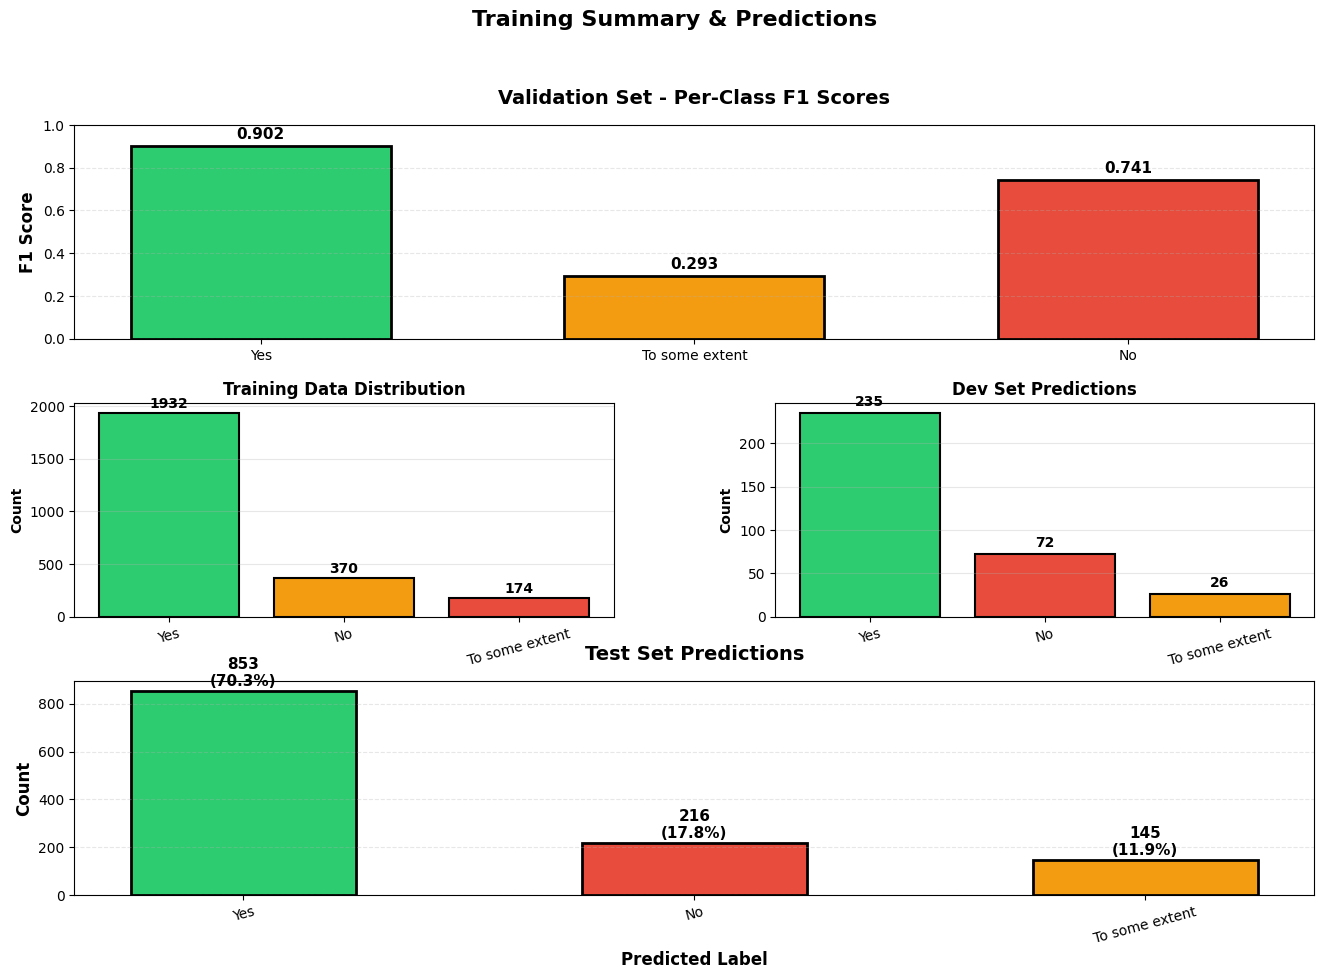

✓ Training summary visualization saved to: training_summary.png


In [96]:
# Create training summary
print(f"\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")
print(f"Model: {MODEL_NAME}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nValidation Set Performance:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

print(f"\n{'='*80}")
print("PREDICTIONS GENERATED")
print(f"{'='*80}")
print(f"✓ Dev set: {len(dev_results_df)} predictions → dev_predictions.csv")
print(f"✓ Test set: {len(test_results_df)} predictions → test_predictions.csv")
print(f"{'='*80}\n")

# Create visualization comparing training performance and prediction distributions
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Validation Set - Per-Class F1
ax1 = fig.add_subplot(gs[0, :])
class_names = ['Yes', 'To some extent', 'No']
val_f1_scores = [val_results['eval_f1_yes'], val_results['eval_f1_to_some_extent'], val_results['eval_f1_no']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(class_names, val_f1_scores, color=colors, edgecolor='black', linewidth=2, width=0.6)
ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax1.set_title('Validation Set - Per-Class F1 Scores', fontweight='bold', fontsize=14, pad=15)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, score in zip(bars, val_f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Training Data Distribution
ax2 = fig.add_subplot(gs[1, 0])
train_counts = train_df['label'].value_counts()
bars = ax2.bar(train_counts.index, train_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Training Data Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, train_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, count + 20, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 3. Dev Set Predictions
ax3 = fig.add_subplot(gs[1, 1])
dev_pred_counts = pd.Series([id2label[label] for label in dev_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in dev_pred_counts.index]
bars = ax3.bar(dev_pred_counts.index, dev_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=1.5)
ax3.set_title('Dev Set Predictions', fontweight='bold', fontsize=12)
ax3.set_ylabel('Count', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, dev_pred_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 4. Test Set Predictions
ax4 = fig.add_subplot(gs[2, :])
test_pred_counts = pd.Series([id2label[label] for label in test_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in test_pred_counts.index]
bars = ax4.bar(test_pred_counts.index, test_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=2, width=0.5)
ax4.set_title('Test Set Predictions', fontweight='bold', fontsize=14, pad=15)
ax4.set_ylabel('Count', fontweight='bold', fontsize=12)
ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, test_pred_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, count + 10, 
            f'{count}\n({count/len(test_pred_labels)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Training Summary & Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training summary visualization saved to: training_summary.png")

## 14. Final Summary

In [97]:
print(f"\n{'='*80}")
print("🎉 TRAINING & PREDICTION COMPLETE!")
print(f"{'='*80}")
print(f"\n✅ Model trained successfully on {len(train_dataset)} samples")
print(f"✅ Validation F1-Macro: {val_results['eval_f1_macro']:.4f}")
print(f"✅ Predictions generated for {len(dev_results_df)} dev samples")
print(f"✅ Predictions generated for {len(test_results_df)} test samples")

print(f"\n📁 Output Files:")
print(f"  - best_model/mistake-identification/ → Trained model & tokenizer")
print(f"  - dev_predictions.csv → Dev set predictions with probabilities")
print(f"  - test_predictions.csv → Test set predictions with probabilities")
print(f"  - confusion_matrix_validation.png → Validation confusion matrix")
print(f"  - prediction_distributions.png → Pred distributions for dev/test")
print(f"  - training_summary.png → Complete training summary")
print(f"  - label_distribution.png → Training data distribution")

print(f"\n📊 Next Steps:")
print(f"  1. Review predictions in CSV files")
print(f"  2. Analyze model confidence scores (probabilities)")
print(f"  3. Use model for inference on new conversations")
print(f"  4. Fine-tune if needed based on domain feedback")

print(f"\n{'='*80}\n")


🎉 TRAINING & PREDICTION COMPLETE!

✅ Model trained successfully on 1980 samples
✅ Validation F1-Macro: 0.6454
✅ Predictions generated for 333 dev samples
✅ Predictions generated for 1214 test samples

📁 Output Files:
  - best_model/mistake-identification/ → Trained model & tokenizer
  - dev_predictions.csv → Dev set predictions with probabilities
  - test_predictions.csv → Test set predictions with probabilities
  - confusion_matrix_validation.png → Validation confusion matrix
  - prediction_distributions.png → Pred distributions for dev/test
  - training_summary.png → Complete training summary
  - label_distribution.png → Training data distribution

📊 Next Steps:
  1. Review predictions in CSV files
  2. Analyze model confidence scores (probabilities)
  3. Use model for inference on new conversations
  4. Fine-tune if needed based on domain feedback




## 🎉 Complete!

### Summary
- **Model**: DeBERTa-v3-base (Microsoft)
- **Task**: 3-class mistake identification
- **Training**: 2,400 samples with 80/20 train/val split
- **Inference**: Dev (328 samples) + Test (1,200 samples)

### Key Features
✓ State-of-the-art DeBERTa for nuanced understanding  
✓ Weighted loss to handle class imbalance  
✓ Early stopping to prevent overfitting  
✓ Comprehensive validation metrics  
✓ Predictions with confidence scores  

### Output Files
- `best_model/mistake-identification/` - Trained model & tokenizer
- `dev_predictions.csv` - Dev set predictions with probabilities
- `test_predictions.csv` - Test set predictions with probabilities
- `confusion_matrix_validation.png` - Validation confusion matrix
- `prediction_distributions.png` - Distribution visualizations
- `training_summary.png` - Complete training summary
- `label_distribution.png` - Training data distribution

### Using Predictions
The CSV files contain:
- `conversation_history` - Original conversation
- `tutor_response` - Tutor's response
- `predicted_label` - Model's prediction (Yes/To some extent/No)
- `prob_yes`, `prob_to_some_extent`, `prob_no` - Confidence scores

### Next Steps
1. Review predictions and confidence scores
2. Use the model for real-time inference
3. Fine-tune on additional labeled data if available
4. Deploy for production use